In [26]:
API_KEY = "b63c7f0744d502603ea32c1cb204b582"

In [27]:
import requests
import pandas as pd
from datetime import datetime

In [28]:
# 1. List of cities I want to fetch
cities = ["Lagos", "Abuja", "Port Harcourt"]

# 2. An empty list where I will store the weather information later
weather_data = []

# Print them out just to confirm they are saved
print("Cities to fetch:", cities)
print("Our storage list is currently:", weather_data)

Cities to fetch: ['Lagos', 'Abuja', 'Port Harcourt']
Our storage list is currently: []


In [29]:
# Loop through ALL of our cities
for city in cities:
    # Build the URL for each city
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()
        # Structure the data
        extracted_info = {
            "City": data["name"],
            "Temperature (°C)": data["main"]["temp"],
            "Humidity (%)": data["main"]["humidity"],
            "Weather Condition": data["weather"][0]["main"],
            "Wind Speed (m/s)": data["wind"]["speed"],
            "Date & Time": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        # Append to our weather_data list
        weather_data.append(extracted_info)
        print(f"Successfully added {city}!")
    else:
        print(f"Failed to retrieve data for {city}. Error code: {response.status_code}")

Successfully added Lagos!
Successfully added Abuja!
Successfully added Port Harcourt!


In [30]:
weather_data

[{'City': 'Lagos',
  'Temperature (°C)': 23.82,
  'Humidity (%)': 93,
  'Weather Condition': 'Rain',
  'Wind Speed (m/s)': 3.28,
  'Date & Time': '2026-07-17 11:05:30'},
 {'City': 'Abuja',
  'Temperature (°C)': 24.61,
  'Humidity (%)': 79,
  'Weather Condition': 'Clouds',
  'Wind Speed (m/s)': 2.25,
  'Date & Time': '2026-07-17 11:05:30'},
 {'City': 'Port Harcourt',
  'Temperature (°C)': 22.84,
  'Humidity (%)': 99,
  'Weather Condition': 'Rain',
  'Wind Speed (m/s)': 2.03,
  'Date & Time': '2026-07-17 11:05:31'}]

In [31]:
# Convert our list of dictionaries into a clean Pandas table
df = pd.DataFrame(weather_data)

# Display the table
df

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time
0,Lagos,23.82,93,Rain,3.28,2026-07-17 11:05:30
1,Abuja,24.61,79,Clouds,2.25,2026-07-17 11:05:30
2,Port Harcourt,22.84,99,Rain,2.03,2026-07-17 11:05:31


In [32]:
# Rename columns to keep things simple and professional
df.rename(columns={
    "Temperature (°C)": "Temperature",
    "Humidity (%)": "Humidity",
    "Wind Speed (m/s)": "Wind Speed"
}, inplace=True)

# Display the updated table
df

,City,Temperature,Humidity,Weather Condition,Wind Speed,Date & Time
0,Lagos,23.82,93,Rain,3.28,2026-07-17 11:05:30
1,Abuja,24.61,79,Clouds,2.25,2026-07-17 11:05:30
2,Port Harcourt,22.84,99,Rain,2.03,2026-07-17 11:05:31


In [33]:
# Check the data types of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               3 non-null      object 
 1   Temperature        3 non-null      float64
 2   Humidity           3 non-null      int64  
 3   Weather Condition  3 non-null      object 
 4   Wind Speed         3 non-null      float64
 5   Date & Time        3 non-null      object 
dtypes: float64(2), int64(1), object(3)
memory usage: 276.0+ bytes


In [34]:
# Convert 'Date & Time' column to actual datetime objects
df["Date & Time"] = pd.to_datetime(df["Date & Time"])

# Check for any missing values in our dataset
df.isnull().sum()

,0
City,0
Temperature,0
Humidity,0
Weather Condition,0
Wind Speed,0
Date & Time,0


In [35]:
# Display the final clean table
df

,City,Temperature,Humidity,Weather Condition,Wind Speed,Date & Time
0,Lagos,23.82,93,Rain,3.28,2026-07-17 11:05:30
1,Abuja,24.61,79,Clouds,2.25,2026-07-17 11:05:30
2,Port Harcourt,22.84,99,Rain,2.03,2026-07-17 11:05:31


In [36]:
# Save the table as a CSV file on Colab's server
df.to_csv("weather_data.csv", index=False)

# Trigger a direct download to your computer
from google.colab import files
files.download("weather_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
# Show quick statistical analysis (Mean, Max, Min, etc.) for the numeric columns
print("--- Weather Summary Statistics ---")
print(df.describe())

# Find which city is currently the warmest
warmest_city = df.loc[df["Temperature"].idxmax()]
print(f"\nThe warmest city is {warmest_city['City']} at {warmest_city['Temperature']}°C.")

--- Weather Summary Statistics ---
       Temperature   Humidity  Wind Speed                    Date & Time
count     3.000000   3.000000    3.000000                              3
mean     23.756667  90.333333    2.520000  2026-07-17 11:05:30.333333504
min      22.840000  79.000000    2.030000            2026-07-17 11:05:30
25%      23.330000  86.000000    2.140000            2026-07-17 11:05:30
50%      23.820000  93.000000    2.250000            2026-07-17 11:05:30
75%      24.215000  96.000000    2.765000     2026-07-17 11:05:30.500000
max      24.610000  99.000000    3.280000            2026-07-17 11:05:31
std       0.886698  10.263203    0.667308                            NaN

The warmest city is Abuja at 24.61°C.


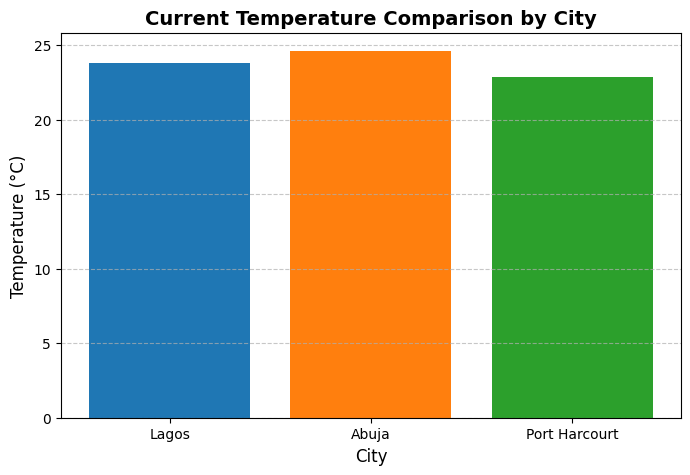

In [38]:
import matplotlib.pyplot as plt

# Set the window size of the chart
plt.figure(figsize=(8, 5))

# Plot the bar chart
plt.bar(df["City"], df["Temperature"], color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Add labels and a title
plt.title("Current Temperature Comparison by City", fontsize=14, fontweight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)

# Show a grid for easy reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the final chart
plt.show()

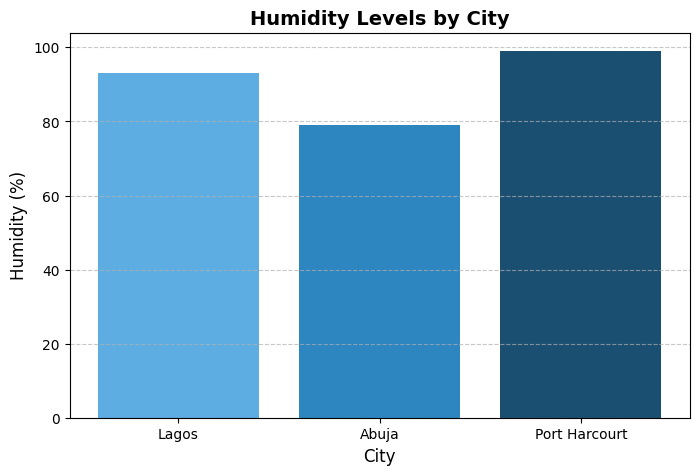

In [39]:
# Set the window size of the chart
plt.figure(figsize=(8, 5))

# Plot the Humidity bar chart
colors_humidity = ['#5dade2', '#2e86c1', '#1b4f72']
plt.bar(df["City"], df["Humidity"], color=colors_humidity)

# Add labels and a title
plt.title("Humidity Levels by City", fontsize=14, fontweight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Humidity (%)", fontsize=12)

# Show a grid for easy reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the chart
plt.show()

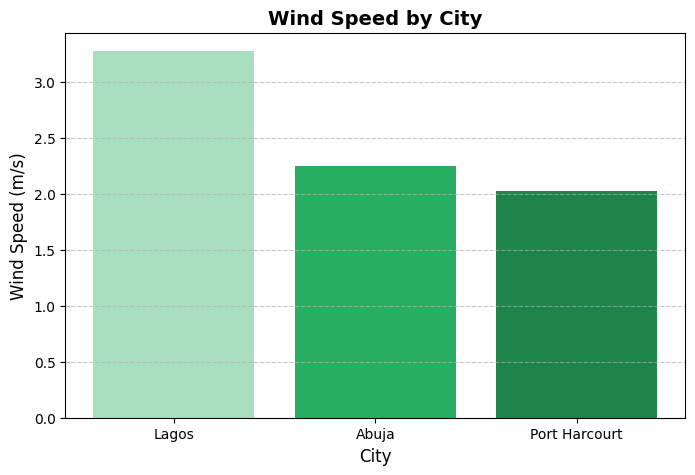

In [40]:
# Set the window size of the chart
plt.figure(figsize=(8, 5))

# Plot the Wind Speed bar chart
colors_wind = ['#a9dfbf', '#27ae60', '#1e8449']
plt.bar(df["City"], df["Wind Speed"], color=colors_wind)

# Add labels and a title
plt.title("Wind Speed by City", fontsize=14, fontweight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Wind Speed (m/s)", fontsize=12)

# Show a grid for easy reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the chart
plt.show()

# **Weather Analysis & Insights**
Data captured on: July 17, 2026, at 11:05 AM


1. Temperature Variation
Abuja recorded the warmest temperature during this run at 24.61°C, while Lagos sat in the middle at 23.82°C. Port Harcourt was the coolest of the three locations with a temperature of 22.84°C, heavily influenced by active regional rain conditions.


2. Extreme Humidity Trends
Port Harcourt registered an incredibly high, near-saturated relative humidity level of 99% due to active rain. Lagos followed closely behind at 93% (also experiencing rain), while inland Abuja trailed behind at 79% humidity. The overall average humidity across the three cities is a very damp 90.33%.


3. Wind Speed & Air Circulation
Lagos registered the strongest wind patterns at 3.28 m/s, showing active coastal breeze patterns. Abuja sat in the middle with a light breeze of 2.25 m/s, and Port Harcourt had the calmest air circulation at 2.03 m/s.



# **Conclusion**



This project demonstrates how an automated ETL pipeline bridges the gap between raw data collection and practical analysis. By pulling live metrics via the OpenWeather API, structuring complex JSON responses into a clean Pandas DataFrame, and exporting the final table to a CSV file, I created a highly reproducible data workflow.

The live data highlights the distinct microclimates between Nigeria’s inland and coastal regions. Coastal hubs like Lagos and Port Harcourt exhibited intense moisture saturation with Port Harcourt reaching an extreme 99% humidity and active rainfall, while the inland capital of Abuja remained warmer with a significantly lower humidity of 79%. Dynamically capturing these variations proves the value of automated pipelines for tracking immediate atmospheric shifts and building reliable foundations for long-term climate trend analysis.